In [1]:
import pandas as pd
import json
from tqdm import tqdm

from utils.subgraph_functions import  prune_triples, restore_full_triples, get_full_uri
from utils.helper_functions import read_jsonl_file, save_as_jsonl, decode_underscored_unicode
from utils.subgraph_functions import create_graph_from_triples, plot_graph_with_simplified_labels
from utils.subgraph_functions import build_minimal_subgraph_Steiner, largest_connected_subgraph, edges_to_triples



In [2]:
split = 'test'
directory = f"/home/ec2-user/preetam_experiments/"

df = pd.read_json(f"{directory}/outputs/{split}/cleaned_subgraph_df_{split}.json", orient="records")

res_file = read_jsonl_file(f"{directory}/batch_processing_files/{split}/results/llm_requests_{split}_out.jsonl")

In [3]:
df

,subgraph_Steiner,subgraph_Steiner_length,subgraph_Steiner_largest_connected,subgraph_Steiner_largest_connected_length,QID,unwanted_filter_flag,unwanted_percentage
0,[[http://yago-knowledge.org/resource/Old__u002...,30,[[http://yago-knowledge.org/resource/Camelidae...,15,97855,False,0.000000
1,[[http://yago-knowledge.org/resource/Barry_Ban...,13,[[http://yago-knowledge.org/resource/Barry_Ban...,11,39548,False,0.000000
2,[[http://yago-knowledge.org/resource/Joseph_Ma...,16,[[http://yago-knowledge.org/resource/Joseph_Ma...,14,118880,False,0.000000
3,[[http://yago-knowledge.org/resource/Joe_Keena...,17,[[http://yago-knowledge.org/resource/Joe_Keena...,13,31930,False,0.000000
4,[[http://yago-knowledge.org/resource/Standards...,20,[[http://yago-knowledge.org/resource/Mzla_Tech...,17,97616,False,0.000000
...,...,...,...,...,...,...,...
19995,[[http://yago-knowledge.org/resource/Building_...,44,[[http://yago-knowledge.org/resource/Building_...,33,86508,True,45.454545
19996,[[http://yago-knowledge.org/resource/Reggie_Mi...,33,[[http://yago-knowledge.org/resource/Reggie_Mi...,33,50516,True,45.454545
19997,[[http://yago-knowledge.org/resource/Emma_Thom...,42,[[http://yago-knowledge.org/resource/Emma_Thom...,33,120462,True,45.454545
19998,"[[http://yago-knowledge.org/resource/China, ht...",17,"[[http://yago-knowledge.org/resource/China, ht...",11,94732,True,45.454545


In [4]:
data_dict = {
    'id':[],
    'question_num':[],
    'question':[],
    'answer':[],
    'answer_readable':[],
    'answer_uri':[],
    'supporting_facts':[],
    'supporting_facts_uri':[],
    # 'supporting_path_uri':[],
    'subgraph':[],
    'subgraph_size':[]}

In [5]:
failed_idx = []
incomplete_paths = []
for idx in tqdm(range(len(df))): 
    try:
        response = json.loads(res_file[idx]['modelOutput']['content'][0]['text'])
        if response['valid_qa_pairs']:
            qa_pairs = response['qa_pairs']
            for qnum in range(len(qa_pairs)):
                supporting_path_uri = restore_full_triples(qa_pairs[qnum]['supporting_path'], df.iloc[idx]['subgraph_Steiner_largest_connected'])
                if supporting_path_uri[1] == False:
                    failed_idx.append(f'QID: {df.iloc[idx]["QID"]}, QNUM: {qnum}')
                    continue
                
                answer_node = get_full_uri(qa_pairs[qnum]['answer'], supporting_path_uri[0])
                if answer_node == None:
                    failed_idx.append(f'QID: {df.iloc[idx]["QID"]}, QNUM: {qnum}')
                    continue
                
                # #check connectivity of the supporting path
                # graph = create_graph_from_triples(supporting_path_uri[0])
                # largest_connected = largest_connected_subgraph(graph)
                # largest_connected_triples = edges_to_triples(largest_connected)
                
                # if len(largest_connected_triples) != len(supporting_path_uri[0]):
                #     connected_rp = build_minimal_subgraph_Steiner(largest_connected, list(graph.nodes()))
                #     supporting_path_uri_connected = edges_to_triples(connected_rp)
                #     incomplete_paths.append((supporting_path_uri[0], df.iloc[idx]['subgraph_Steiner_largest_connected'],
                #                              supporting_path_uri_connected, 
                #                              qa_pairs[qnum]['answer'], qa_pairs[qnum]['question']))
                    
                # else:
                #     supporting_path_uri_connected = supporting_path_uri[0]
                
                
                data_dict['answer'].append(qa_pairs[qnum]['answer'])
                data_dict['answer_uri'].append(answer_node)
                data_dict['answer_readable'].append(decode_underscored_unicode(qa_pairs[qnum]['answer']))
                
                data_dict['supporting_facts'].append(qa_pairs[qnum]['supporting_path'])
                data_dict['supporting_facts_uri'].append(supporting_path_uri[0])
                # data_dict['supporting_path_uri'].append(supporting_path_uri_connected)
                    
                data_dict['id'].append(df.iloc[idx]['QID'])
                data_dict['question_num'].append(qnum)
                data_dict['question'].append(qa_pairs[qnum]['question'])

                
                data_dict['subgraph'].append(df.iloc[idx]['subgraph_Steiner_largest_connected'])
                data_dict['subgraph_size'].append(df.iloc[idx]['subgraph_Steiner_largest_connected_length'])
    except:
        failed_idx.append(f'QID: {df.iloc[idx]["QID"]}')
        # print(f'QID: {df.iloc[idx]["QID"]}')
        continue
    

  6%|▌         | 1151/20000 [00:00<00:12, 1548.70it/s]

100%|██████████| 20000/20000 [00:13<00:00, 1504.61it/s]


In [9]:
len(failed_idx)

3461

In [6]:
df_n = pd.DataFrame(data_dict)

In [7]:
df_n

,id,question_num,question,answer,answer_readable,answer_uri,supporting_facts,supporting_facts_uri,subgraph,subgraph_size
0,97855,0,"What family does the alpaca belong to, conside...",Camelidae,Camelidae,http://yago-knowledge.org/resource/Camelidae,"[{'subject': 'Alpaca', 'predicate': 'parentTax...","[[http://yago-knowledge.org/resource/Alpaca, h...",[[http://yago-knowledge.org/resource/Camelidae...,15
1,97855,1,Which broader taxonomic group includes both th...,Camelidae,Camelidae,http://yago-knowledge.org/resource/Camelidae,"[{'subject': 'Guanaco', 'predicate': 'parentTa...","[[http://yago-knowledge.org/resource/Guanaco, ...",[[http://yago-knowledge.org/resource/Camelidae...,15
2,97855,2,What is the highest-level taxonomic group that...,Even-toed_ungulate,Even-toed ungulate,http://yago-knowledge.org/resource/Even-toed_u...,"[{'subject': 'Chevrotain', 'predicate': 'paren...",[[http://yago-knowledge.org/resource/Chevrotai...,[[http://yago-knowledge.org/resource/Camelidae...,15
3,39548,0,Which football club owned Villa Park and parti...,Aston_Villa_F_u002E_C_u002E_,Aston Villa F.C.,http://yago-knowledge.org/resource/Aston_Villa...,"[{'subject': 'Villa_Park', 'predicate': 'owned...",[[http://yago-knowledge.org/resource/Villa_Par...,[[http://yago-knowledge.org/resource/Barry_Ban...,11
4,39548,1,Which player was a member of both Aston Villa ...,Gary_Cahill,Gary Cahill,http://yago-knowledge.org/resource/Gary_Cahill,"[{'subject': 'Gary_Cahill', 'predicate': 'memb...",[[http://yago-knowledge.org/resource/Gary_Cahi...,[[http://yago-knowledge.org/resource/Barry_Ban...,11
...,...,...,...,...,...,...,...,...,...,...
53920,120462,2,Which male actor appeared in House and shares ...,Nathan_Kress,Nathan Kress,http://yago-knowledge.org/resource/Nathan_Kress,"[{'subject': 'House__u0028_TV_series_u0029_', ...",[[http://yago-knowledge.org/resource/House__u0...,[[http://yago-knowledge.org/resource/Emma_Thom...,33
53921,94732,0,Which movie director shares the same nationali...,Sammo Hung,Sammo Hung,http://yago-knowledge.org/resource/Sammo_Hung,"[{'subject': 'South_Korea', 'predicate': 'neig...",[[http://yago-knowledge.org/resource/South_Kor...,"[[http://yago-knowledge.org/resource/China, ht...",11
53922,94732,1,In which historical kingdom was the mother of ...,Joseon,Joseon,http://yago-knowledge.org/resource/Joseon,[{'subject': 'Royal_Noble_Consort_Yeongbin_Yi'...,[[http://yago-knowledge.org/resource/Royal_Nob...,"[[http://yago-knowledge.org/resource/China, ht...",11
53923,65177,0,Which language would Frank Chodorov's organiza...,English_language_generic_instance,English language generic instance,http://yago-knowledge.org/resource/English_lan...,"[{'subject': 'Frank_Chodorov', 'predicate': 'n...",[[http://yago-knowledge.org/resource/Frank_Cho...,[[http://yago-knowledge.org/resource/Prince__u...,11


In [10]:
df_n.to_json(f"{directory}/batch_processing_files/{split}/qa_pairs_{split}.json", orient="records")

Nvidia
[('http://yago-knowledge.org/resource/David_J_u002E__Brown__u0028_computer_scientist_u0029_', 'http://schema.org/worksFor', 'http://yago-knowledge.org/resource/Sun_Microsystems')]


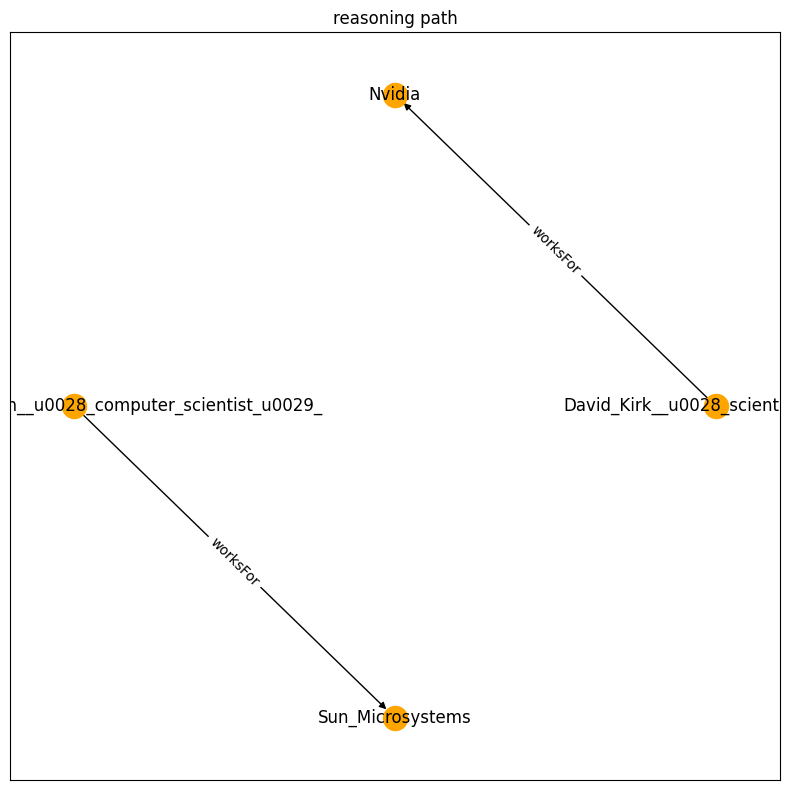

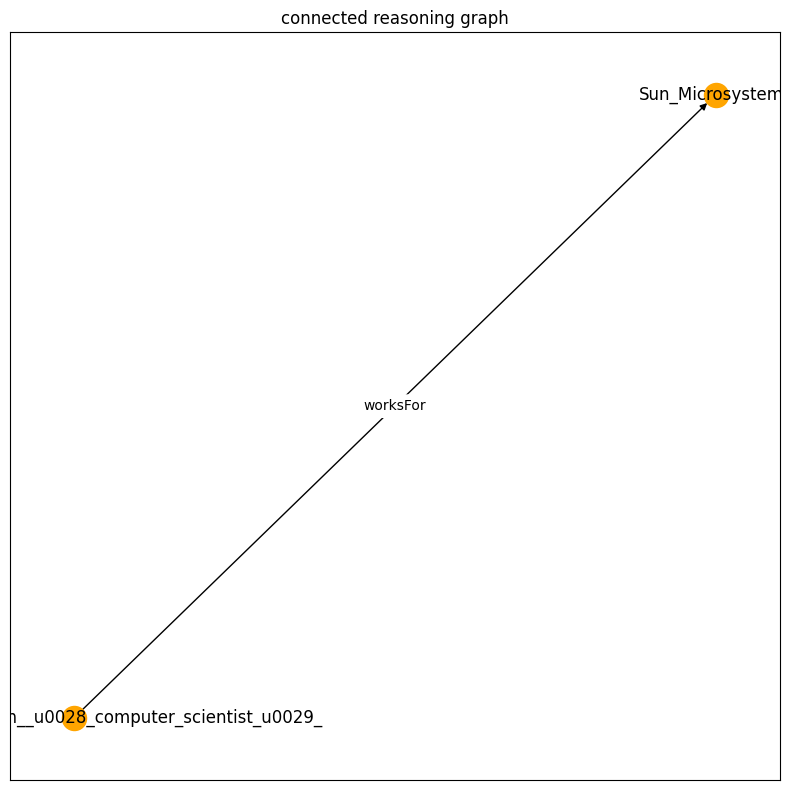

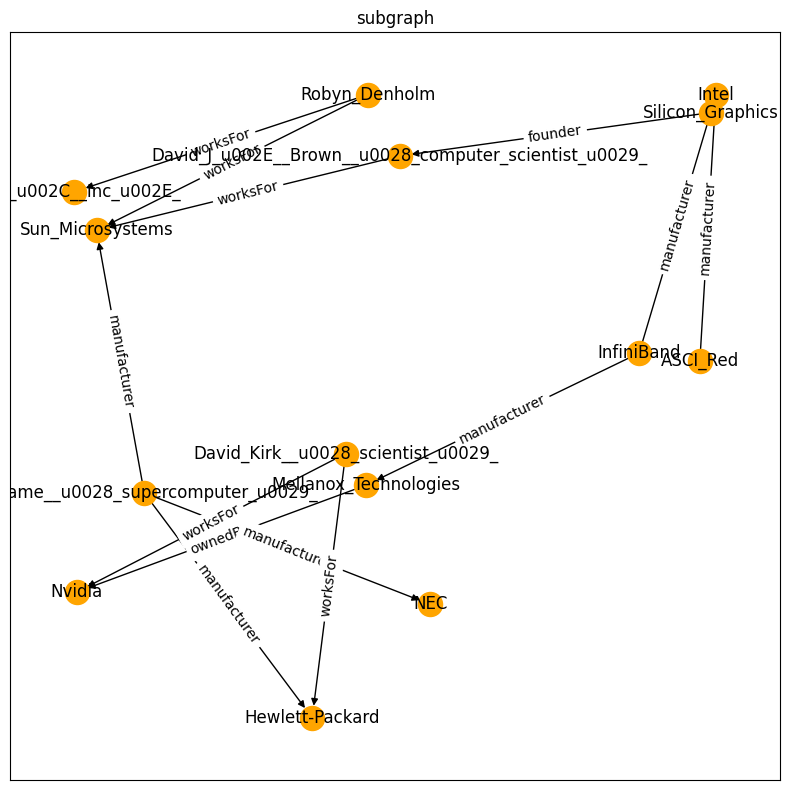

In [17]:
j = 9
graph_r = create_graph_from_triples(incomplete_paths[j][0])
graph_f = create_graph_from_triples(incomplete_paths[j][1])
graph_c = create_graph_from_triples(incomplete_paths[j][2])
print(incomplete_paths[j][3])
print(incomplete_paths[j][2])

plot_graph_with_simplified_labels(graph_r, 'reasoning path')
plot_graph_with_simplified_labels(graph_c, 'connected reasoning graph')
plot_graph_with_simplified_labels(graph_f, 'subgraph')

In [26]:

connected_rp = build_minimal_subgraph_Steiner(graph_f, list(graph_r.nodes()))
supporting_path_uri_connected = edges_to_triples(connected_rp)

/home/ec2-user/claimbenchkg/ClaimBenchKG/yago/utils/subgraph_functions.py:171: FutureWarning: steiner_tree will change default method from 'kou' to 'mehlhorn' in version 3.2.
Set the `method` kwarg to remove this warning.
  steiner_subgraph_und = steiner_tree(G_und, valid_interesting)


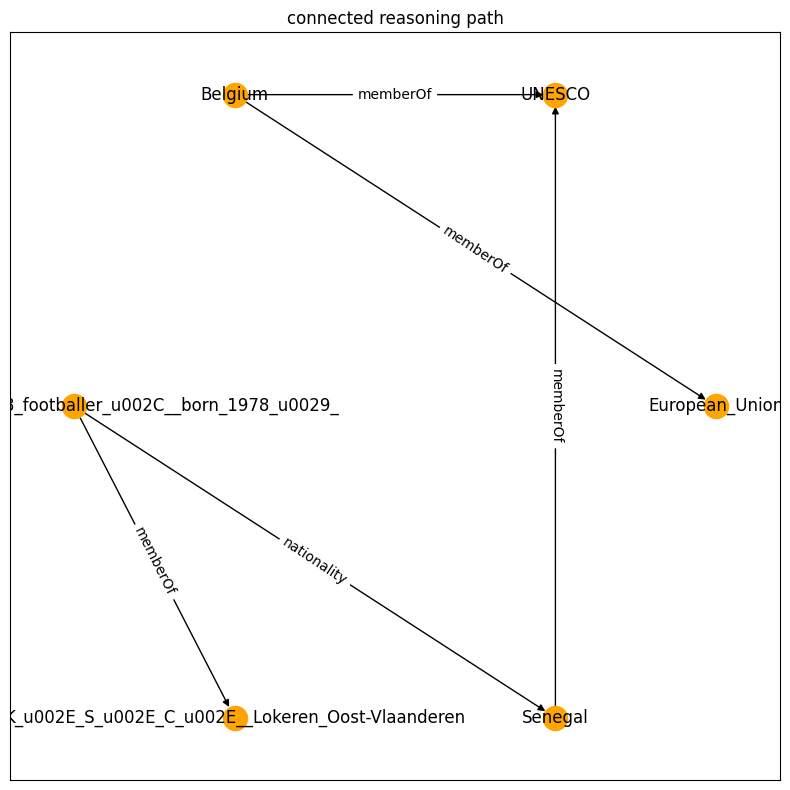

In [27]:
plot_graph_with_simplified_labels(connected_rp, 'connected reasoning path')

In [28]:
edges_to_triples(connected_rp)

[('http://yago-knowledge.org/resource/Ibrahima_Gueye__u0028_footballer_u002C__born_1978_u0029_',
  'http://schema.org/memberOf',
  'http://yago-knowledge.org/resource/K_u002E_S_u002E_C_u002E__Lokeren_Oost-Vlaanderen'),
 ('http://yago-knowledge.org/resource/Ibrahima_Gueye__u0028_footballer_u002C__born_1978_u0029_',
  'http://schema.org/nationality',
  'http://yago-knowledge.org/resource/Senegal'),
 ('http://yago-knowledge.org/resource/Senegal',
  'http://schema.org/memberOf',
  'http://yago-knowledge.org/resource/UNESCO'),
 ('http://yago-knowledge.org/resource/Belgium',
  'http://schema.org/memberOf',
  'http://yago-knowledge.org/resource/European_Union'),
 ('http://yago-knowledge.org/resource/Belgium',
  'http://schema.org/memberOf',
  'http://yago-knowledge.org/resource/UNESCO')]

In [19]:
incomplete_paths[j][0]

[['http://yago-knowledge.org/resource/Ibrahima_Gueye__u0028_footballer_u002C__born_1978_u0029_',
  'http://schema.org/memberOf',
  'http://yago-knowledge.org/resource/K_u002E_S_u002E_C_u002E__Lokeren_Oost-Vlaanderen'],
 ['http://yago-knowledge.org/resource/Belgium',
  'http://schema.org/memberOf',
  'http://yago-knowledge.org/resource/European_Union']]

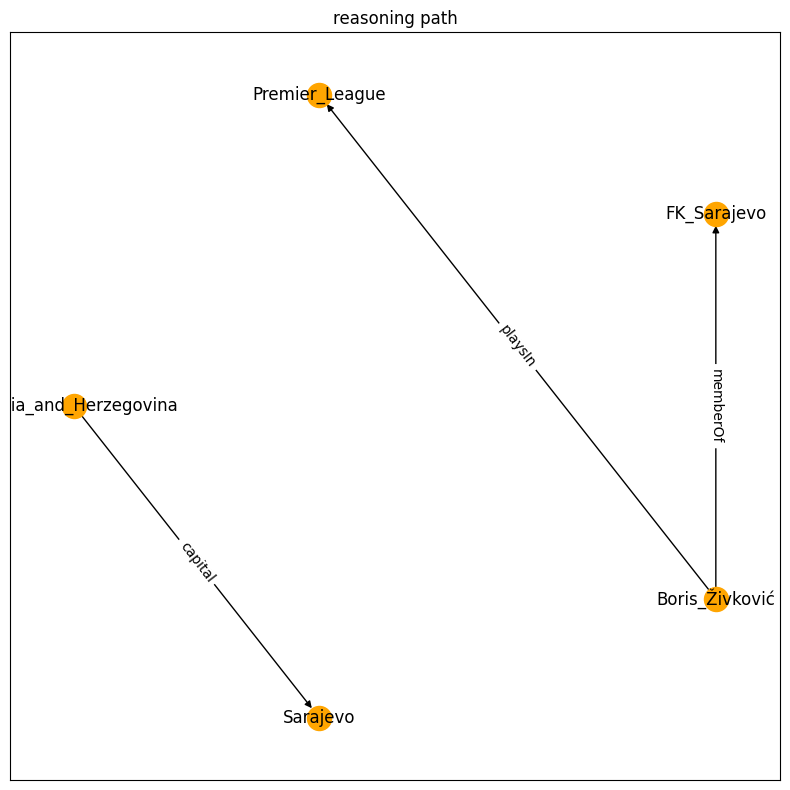

In [11]:

plot_graph_with_simplified_labels(graph, 'reasoning path')

In [23]:
largest_connected = largest_connected_subgraph(graph)
edges_to_triples = edges_to_triples(largest_connected)

In [28]:
len(edges_to_triples) == len(supporting_path_uri[0])

True

In [27]:
supporting_path_uri[0]

[['http://yago-knowledge.org/resource/Rick_Santorum',
  'http://schema.org/nationality',
  'http://yago-knowledge.org/resource/United_States'],
 ['http://yago-knowledge.org/resource/United_States',
  'http://yago-knowledge.org/resource/officialLanguage',
  'http://yago-knowledge.org/resource/English_language_generic_instance']]

In [6]:
len(failed_idx)

9037

In [20]:
decode_underscored_unicode('K_u002E_S_u002E_C_u002E__Lokeren_Oost-Vlaanderen')

'K.S.C. Lokeren Oost-Vlaanderen'

In [9]:
df_n = pd.DataFrame(data_dict)

In [10]:
df_n#[40:60]

,id,question_num,question,answer,answer_readable,answer_uri,supporting_path,supporting_path_uri,subgraph,subgraph_size
0,97855,0,"What family does the alpaca belong to, conside...",Camelidae,Camelidae,http://yago-knowledge.org/resource/Camelidae,"[{'subject': 'Alpaca', 'predicate': 'parentTax...","[[http://yago-knowledge.org/resource/Alpaca, h...",[[http://yago-knowledge.org/resource/Camelidae...,15
1,97855,1,Which broader taxonomic group includes both th...,Camelidae,Camelidae,http://yago-knowledge.org/resource/Camelidae,"[{'subject': 'Guanaco', 'predicate': 'parentTa...","[[http://yago-knowledge.org/resource/Guanaco, ...",[[http://yago-knowledge.org/resource/Camelidae...,15
2,97855,2,What is the highest-level taxonomic group that...,Even-toed_ungulate,Even-toed ungulate,http://yago-knowledge.org/resource/Even-toed_u...,"[{'subject': 'Chevrotain', 'predicate': 'paren...",[[http://yago-knowledge.org/resource/Chevrotai...,[[http://yago-knowledge.org/resource/Camelidae...,15
3,39548,0,Which football club owned Villa Park and parti...,Aston_Villa_F_u002E_C_u002E_,Aston Villa F.C.,http://yago-knowledge.org/resource/Aston_Villa...,"[{'subject': 'Villa_Park', 'predicate': 'owned...",[[http://yago-knowledge.org/resource/Villa_Par...,[[http://yago-knowledge.org/resource/Barry_Ban...,11
4,39548,1,Which player was a member of both Aston Villa ...,Gary_Cahill,Gary Cahill,http://yago-knowledge.org/resource/Gary_Cahill,"[{'subject': 'Gary_Cahill', 'predicate': 'memb...",[[http://yago-knowledge.org/resource/Gary_Cahi...,[[http://yago-knowledge.org/resource/Barry_Ban...,11
...,...,...,...,...,...,...,...,...,...,...
56977,120462,2,Which male actor appeared in House and shares ...,Nathan_Kress,Nathan Kress,http://yago-knowledge.org/resource/Nathan_Kress,"[{'subject': 'House__u0028_TV_series_u0029_', ...",[[http://yago-knowledge.org/resource/House__u0...,[[http://yago-knowledge.org/resource/Emma_Thom...,33
56978,94732,0,Which movie director shares the same nationali...,Sammo Hung,Sammo Hung,http://yago-knowledge.org/resource/Sammo_Hung,"[{'subject': 'South_Korea', 'predicate': 'neig...",[[http://yago-knowledge.org/resource/South_Kor...,"[[http://yago-knowledge.org/resource/China, ht...",11
56979,94732,1,In which historical kingdom was the mother of ...,Joseon,Joseon,http://yago-knowledge.org/resource/Joseon,[{'subject': 'Royal_Noble_Consort_Yeongbin_Yi'...,[[http://yago-knowledge.org/resource/Royal_Nob...,"[[http://yago-knowledge.org/resource/China, ht...",11
56980,65177,0,Which language would Frank Chodorov's organiza...,English_language_generic_instance,English language generic instance,http://yago-knowledge.org/resource/English_lan...,"[{'subject': 'Frank_Chodorov', 'predicate': 'n...",[[http://yago-knowledge.org/resource/Frank_Cho...,[[http://yago-knowledge.org/resource/Prince__u...,11


In [20]:
df_n.iloc[56981]['question']

'What language would Rick Santorum, as an American political figure, primarily communicate in?'

In [ ]:
df_n.to_json(f"{directory}/outputs/{split}/llm_requests_{split}_out.json", orient="records")